# **Import Library**

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import xgboost as xgb
from scipy.optimize import brentq
from google.colab import drive
from numpy.linalg import eigh, svd
from scipy.linalg import hankel
from scipy.signal import periodogram
from scipy.signal import welch
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# **Input Data**

In [ ]:
# Read Data
drive.mount('/content/drive')
data = pd.read_csv(
    "/content/drive/MyDrive/Data Skripsi.csv",
    sep=",",
    decimal=".")

data["Tanggal"] = pd.to_datetime(
    data["Tanggal"],
    format="%m/%d/%Y",
    errors="coerce")
data.set_index("Tanggal", inplace=True)
df = data[["Nilai"]].copy()

start_date = pd.to_datetime("2022-01-01")
end_date = pd.to_datetime("2026-04-15")
df = df[
    (df.index >= start_date) &
    (df.index <= end_date)
].copy()
df = df.sort_index()
display(df.head())
display(df.tail())

Mounted at /content/drive


,Nilai
Tanggal,
2022-01-03,14270
2022-01-04,14310
2022-01-05,14365
2022-01-06,14396
2022-01-07,14360


,Nilai
Tanggal,
2026-04-09,17082
2026-04-10,17112
2026-04-13,17122
2026-04-14,17135
2026-04-15,17141


In [ ]:
# Ringkasan Data
ringkasan_data = pd.DataFrame({
    "Keterangan": [
        "Periode Awal",
        "Periode Akhir",
        "Total Observasi",
        "Frekuensi"
    ],
    "Nilai": [
        df.index.min().date(),
        df.index.max().date(),
        len(df),
        pd.infer_freq(df.index) or "Daily"
    ]
})

display(ringkasan_data)

,Keterangan,Nilai
0,Periode Awal,2022-01-03
1,Periode Akhir,2026-04-15
2,Total Observasi,1025
3,Frekuensi,Daily


In [ ]:
# Cuplikan Data
data_januari_2022 = df[(df.index.year == 2022) & (df.index.month == 1)]
print("Sepuluh data pertama")
display(data_januari_2022.head(10))
print("Sepuluh data terakhir")
display(df.tail(10))

Sepuluh data pertama


,Nilai
Tanggal,
2022-01-03,14270
2022-01-04,14310
2022-01-05,14365
2022-01-06,14396
2022-01-07,14360
2022-01-10,14323
2022-01-11,14299
2022-01-12,14302
2022-01-13,14311


Sepuluh data terakhir


,Nilai
Tanggal,
2026-04-01,17002
2026-04-02,17015
2026-04-06,17037
2026-04-07,17092
2026-04-08,17009
2026-04-09,17082
2026-04-10,17112
2026-04-13,17122
2026-04-14,17135


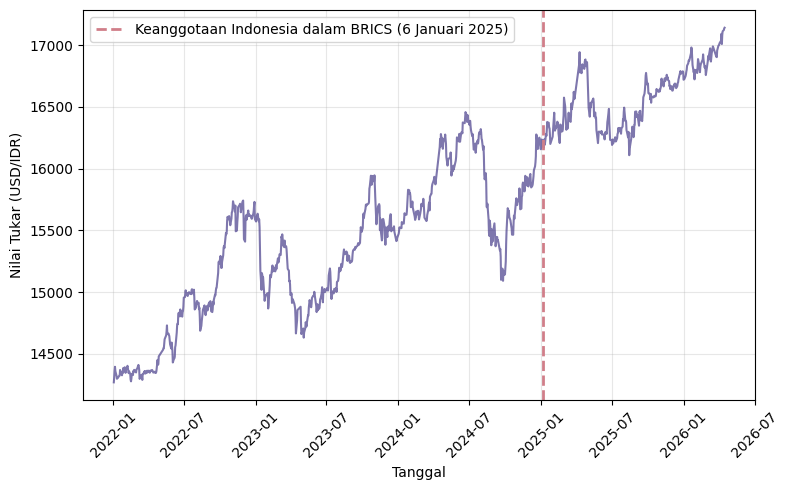

In [ ]:
# Visualisasi Data Nilai Tukar
plt.figure(figsize = (8, 5))
plt.plot(df.index, df["Nilai"], linewidth = 1.5, color = "#483D8B", alpha = 0.7)
plt.axvline(
    pd.to_datetime("2025-01-06"),
    color = "#D07E89",
    linestyle = "--",
    linewidth = 2,
    label = "Keanggotaan Indonesia dalam BRICS (6 Januari 2025)"
)

plt.xlabel("Tanggal")
plt.ylabel("Nilai Tukar (USD/IDR)")
plt.grid(True, alpha = 0.3)
plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

# **Deteksi Outlier**

In [ ]:
# Perhitungan Return
df_return = df.copy()
df_return["Return"] = np.log(df_return["Nilai"] / df_return["Nilai"].shift(1))
df_return = df_return.dropna()

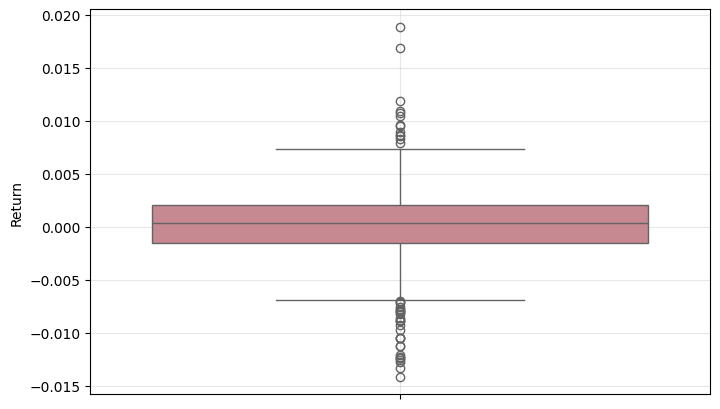

In [ ]:
# Visualisasi Boxplot Return
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_return["Return"], color="#D07E89")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Identifikasi Outlier dengan Metode IQR
Q1 = df_return["Return"].quantile(0.25)
Q3 = df_return["Return"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
outliers = df_return[
    (df_return["Return"] < batas_bawah) |
    (df_return["Return"] > batas_atas)
]
jumlah_outlier = len(outliers)
total_data = len(df_return)
ringkasan_outlier = pd.DataFrame({
    "Keterangan": ["Jumlah Outlier", "Total Data"],
    "Nilai": [jumlah_outlier, total_data]
})

display(ringkasan_outlier)

,Keterangan,Nilai
0,Jumlah Outlier,42
1,Total Data,1024


# **Change-point Detection**

## **Penentuan Parameter l**

In [ ]:
# Parameter untuk Embedding dan SVD
col = "Nilai"
start = 0
N = 360
M = 180
k_plot = 30
n_comp = 30

x_all = df[col].astype(float).values
x_base = x_all[start:start + N]

if len(x_base) < N:
    raise ValueError("Segmen dasar kurang dari N. Cek nilai start atau panjang data.")

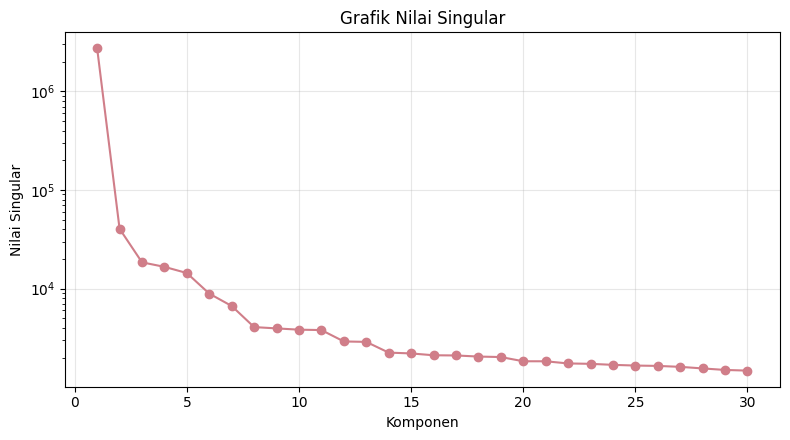

In [ ]:
# Grafik Nilai Singular
def build_trajectory_l(x, M):
    return hankel(x[:M], x[M-1:])

X_l = build_trajectory_l(x_base, M)
S_l = X_l @ X_l.T

eigvals_l, U_l = eigh(S_l)
order_l = np.argsort(eigvals_l)[::-1]
eigvals_l = eigvals_l[order_l]
U_l = U_l[:, order_l]

eigvals_l = np.clip(eigvals_l, 0, None)
singular_vals_l = np.sqrt(eigvals_l)

plt.figure(figsize=(8, 4.5))
plt.plot(
    np.arange(1, k_plot + 1),
    singular_vals_l[:k_plot],
    marker="o",
    linewidth=1.5,
    color="#D07E89"
)
plt.yscale("log")
plt.title("Grafik Nilai Singular")
plt.xlabel("Komponen")
plt.ylabel("Nilai Singular")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Tabel Nilai Singular
contrib_l = eigvals_l / eigvals_l.sum()
cum_contrib_l = np.cumsum(contrib_l)

sv_table = pd.DataFrame({
    "Komponen": np.arange(1, n_comp + 1),
    "Eigenvalue": eigvals_l[:n_comp],
    "Singular Value": singular_vals_l[:n_comp],
    "Kontribusi (%)": contrib_l[:n_comp] * 100,
    "Kumulatif (%)": cum_contrib_l[:n_comp] * 100
})

display(sv_table.round(4))

,Komponen,Eigenvalue,Singular Value,Kontribusi (%),Kumulatif (%)
0,1,7.410615e+12,2.722244e+06,99.9628,99.9628
1,2,1.631501e+09,4.039185e+04,0.0220,99.9848
2,3,3.405367e+08,1.845364e+04,0.0046,99.9894
3,4,2.759768e+08,1.661255e+04,0.0037,99.9931
4,5,2.065843e+08,1.437304e+04,0.0028,99.9959
5,6,7.898583e+07,8.887397e+03,0.0011,99.9969
6,7,4.434964e+07,6.659552e+03,0.0006,99.9975
7,8,1.656238e+07,4.069690e+03,0.0002,99.9978
8,9,1.557443e+07,3.946445e+03,0.0002,99.9980
9,10,1.468009e+07,3.831461e+03,0.0002,99.9982


## **Implementasi SSA untuk Deteksi Change Point**

In [ ]:
# Fungsi Pembentukan  Trajectory Matrix
def build_trajectory(x, M):
    N = len(x)
    return hankel(x[0:M], x[M-1:N])

In [ ]:
# Fungsi Perhitungan Threshold Durbin
def compute_h_durbin(alpha, T_monitor, Q):
    f = lambda h: (T_monitor * h / np.sqrt(2 * np.pi * Q)) * np.exp(-h**2 / 2) - alpha
    return brentq(f, 1.0, 10.0)

In [ ]:
# Fungsi SSA untuk Deteksi Change Point
def ssa_full(x, N, M, l, p, Q, alpha = 0.05, h_method = "durbin"):
    Tlen = len(x)
    q = p + Q
    max_n = min(Tlen - N, Tlen - (q + M - 1))
    if max_n < 0:
        raise ValueError("Panjang data tidak mencukupi untuk parameter yang digunakan.")
    St_series = np.full(max_n + 1, np.nan)
    nu_series = np.full(max_n + 1, np.nan)
    if h_method == "durbin":
        T_monitor = (max_n + 1) / M
        h = compute_h_durbin(alpha, T_monitor, Q)
        H = 1 + np.sqrt(2) * np.sqrt(M - Q/3) / (M * Q) * h
    else:
        raise ValueError("Metode threshold tidak valid.")

    nu_current = None

    for n in range(max_n + 1):
        base_seg = x[n:(n + N)]
        X_base = build_trajectory(base_seg, M)

        test_cols = []
        for j in range(Q):
            start_idx = n + p + j
            end_idx = start_idx + M
            if end_idx <= Tlen:
                test_cols.append(x[start_idx:end_idx])

        if len(test_cols) != Q:
            continue

        test_seg = np.column_stack(test_cols)

        Rn = X_base @ X_base.T
        eigvals, eigvecs = eigh(Rn)
        U = eigvecs[:, -l:]

        proj_sq = np.sum((U.T @ test_seg) ** 2, axis=0)
        norms_sq = np.sum(test_seg ** 2, axis=0)
        Dn = np.sum(norms_sq - proj_sq)
        Dtilde = Dn / (M * Q)

        proj_sq_ref = np.sum((U.T @ X_base) ** 2, axis=0)
        norms_sq_ref = np.sum(X_base ** 2, axis=0)
        Dn_ref = np.sum(norms_sq_ref - proj_sq_ref)
        Dtilde_ref = Dn_ref / (M * (N - M + 1))

        if nu_current is None:
            nu_current = Dtilde_ref

        St = Dtilde / nu_current if nu_current > 0 else np.nan
        St_series[n] = St
        nu_series[n] = nu_current

        if np.isfinite(St) and St < H:
            nu_current = Dtilde_ref

    return {"St_series": St_series, "nu_series": nu_series, "h": h, "H": H, "max_n": max_n}

In [ ]:
# Penentuan Parameter dan Run SSA
best_params = {
    "N": 360,
    "M": 180,
    "l": 5,
    "p": 360,
    "Q": 3,
    "alpha": 0.005,
    "h_method": "durbin"
}

ssa_optimal = ssa_full(df["Nilai"].values, **best_params)
St_optimal = ssa_optimal["St_series"]
H_optimal = ssa_optimal["H"]

In [ ]:
# Identifikasi Change Point
cp_optimal = np.where(St_optimal >= H_optimal)[0]
offset_optimal = best_params["p"] + best_params["Q"] + best_params["M"] - 2
St_dates_optimal = df.index[offset_optimal:offset_optimal + len(St_optimal)]
cp_dates_optimal = St_dates_optimal[cp_optimal]
results_df = pd.DataFrame({
    "Tanggal": cp_dates_optimal,
    "Nilai Statistik": St_optimal[cp_optimal],
    "Threshold": H_optimal
})

display(results_df)

,Tanggal,Nilai Statistik,Threshold
0,2024-04-17,1.132442,1.122056
1,2024-04-18,1.218663,1.122056
2,2024-04-19,1.306534,1.122056
3,2024-04-22,1.379029,1.122056
4,2024-04-23,1.448371,1.122056
...,...,...,...
281,2025-07-29,1.189726,1.122056
282,2025-07-30,1.169178,1.122056
283,2025-07-31,1.142212,1.122056
284,2025-09-25,1.127255,1.122056


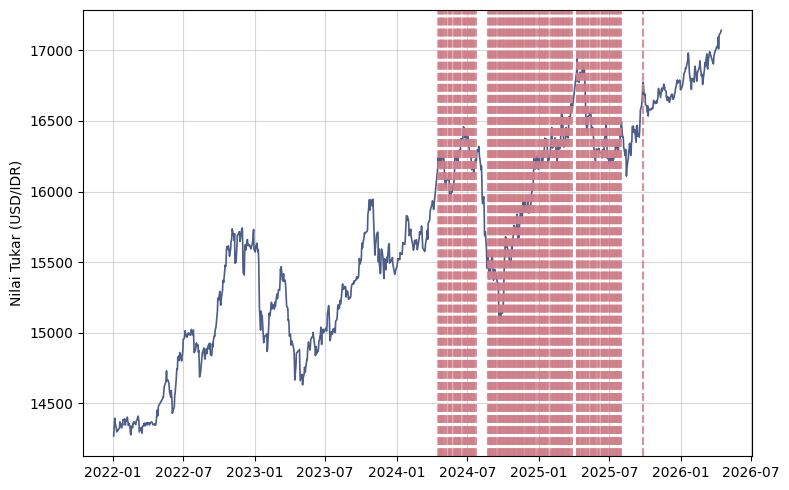

In [ ]:
# Visualisasi Data dengan Change Point
main_color = "#4B5D88"
accent_color = "#D07E89"
plt.figure(figsize=(8, 5))
plt.plot(df.index, df["Nilai"], color = main_color, linewidth= 1.2)
for date in cp_dates_optimal:
    plt.axvline(x = date, color = accent_color, linestyle = "--", alpha = 0.6)

plt.ylabel("Nilai Tukar (USD/IDR)")
plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()

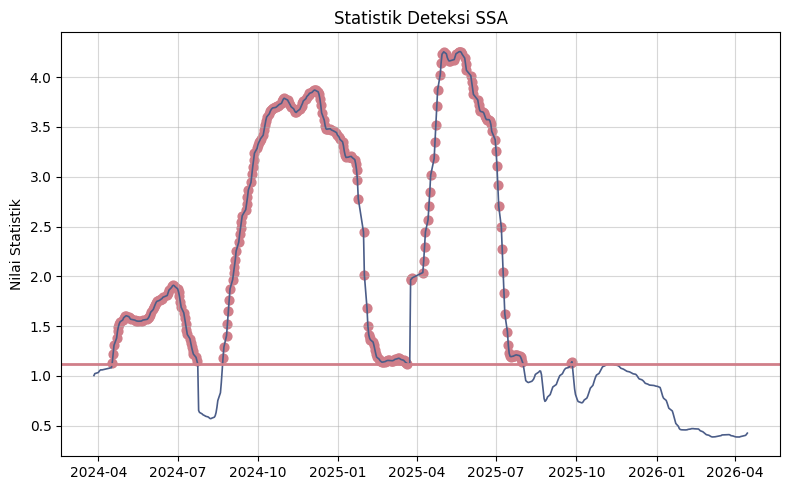

In [ ]:
# Visualisasi Statistik Deteksi SSA
plt.figure(figsize = (8, 5))
plt.plot(St_dates_optimal, St_optimal, color = main_color, linewidth = 1.2)
plt.axhline(y = H_optimal, color = accent_color, linewidth = 2)
plt.scatter(cp_dates_optimal, St_optimal[cp_optimal], color = accent_color, s = 40)
plt.title("Statistik Deteksi SSA")
plt.ylabel("Nilai Statistik")
plt.grid(True, alpha = 0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Pengelompokkan Change Point
gap_days = 5

cp_series = pd.to_datetime(pd.Series(cp_dates_optimal)).sort_values().reset_index(drop=True)
clusters = []

if len(cp_series) > 0:
    start = cp_series.iloc[0]
    prev = cp_series.iloc[0]

    for curr in cp_series.iloc[1:]:
        if (curr - prev).days <= gap_days:
            prev = curr
        else:
            clusters.append((start, prev))
            start = curr
            prev = curr

    clusters.append((start, prev))

cluster_df = pd.DataFrame(clusters, columns=["Start", "End"])

if not cluster_df.empty:
    peak_dates = []
    peak_stats = []

    for _, row in cluster_df.iterrows():
        mask = (St_dates_optimal >= row["Start"]) & (St_dates_optimal <= row["End"])
        seg_stats = St_optimal[mask]
        seg_dates = St_dates_optimal[mask]

        peak_idx = np.argmax(seg_stats)
        peak_dates.append(seg_dates[peak_idx])
        peak_stats.append(seg_stats[peak_idx])

    cluster_df["PeakDate"] = peak_dates
    cluster_df["PeakStat"] = peak_stats

display(cluster_df)

,Start,End,PeakDate,PeakStat
0,2024-04-17,2024-07-23,2024-06-26,1.909353
1,2024-08-22,2025-01-24,2024-12-05,3.871158
2,2025-01-30,2025-03-27,2025-01-30,2.444439
3,2025-04-08,2025-07-31,2025-05-21,4.257562
4,2025-09-25,2025-09-26,2025-09-26,1.141673


In [ ]:
# Titik Tengah dari Cluster 3
cluster_df["MidDate"] = cluster_df["Start"] + (cluster_df["End"] - cluster_df["Start"]) / 2
cluster_df["MidDate"] = cluster_df["MidDate"].dt.round("D")
cluster_idx = 2
if len(cluster_df) > cluster_idx:
    cluster_3 = cluster_df.iloc[cluster_idx]
    start_c3 = cluster_3["Start"]
    end_c3 = cluster_3["End"]
    mid_c3 = cluster_3["MidDate"]
    print("Cluster 3")
    print("Start :", start_c3)
    print("End   :", end_c3)
    print("Mid   :", mid_c3)
else:
    print("Cluster 3 tidak tersedia")

Cluster 3
Start : 2025-01-30 00:00:00
End   : 2025-03-27 00:00:00
Mid   : 2025-02-27 00:00:00


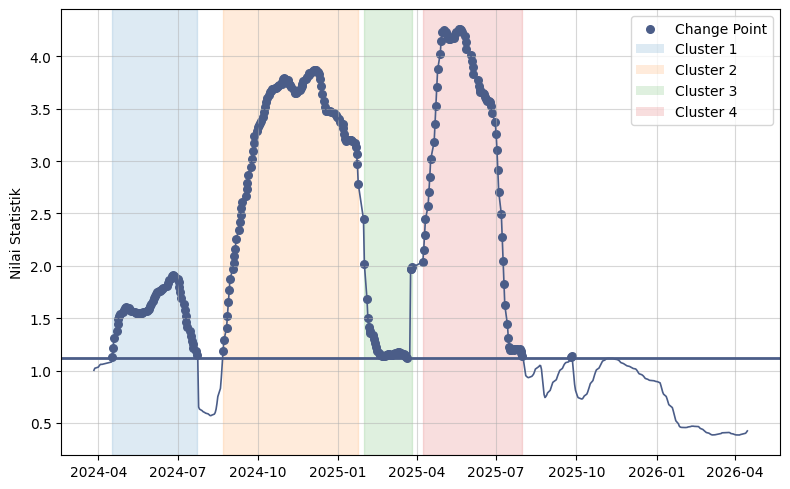

In [ ]:
# Visualisasi Statistik Deteksi SSA
plt.figure(figsize = (8, 5))
plt.plot(St_dates_optimal, St_optimal, color = main_color, linewidth = 1.2)
plt.axhline(y = H_optimal, color = main_color, linewidth = 2)
colors = plt.cm.tab10.colors
legend_patches = []

for i, row in cluster_df.iterrows():
    if i == 4:
        continue
    c = colors[i % len(colors)]
    plt.axvspan(row["Start"], row["End"], color = c, alpha = 0.15)
    legend_patches.append(
        Patch(facecolor=c, alpha = 0.15, label=f"Cluster {i + 1}")
    )
scatter = plt.scatter(
    cp_dates_optimal,
    St_optimal[cp_optimal],
    color = main_color,
    s = 30,
    label = "Change Point"
)

plt.ylabel("Nilai Statistik")
plt.grid(True, alpha=0.5)
handles = [scatter] + legend_patches
labels = [h.get_label() for h in handles]

plt.legend(handles, labels)
plt.tight_layout()
plt.show()

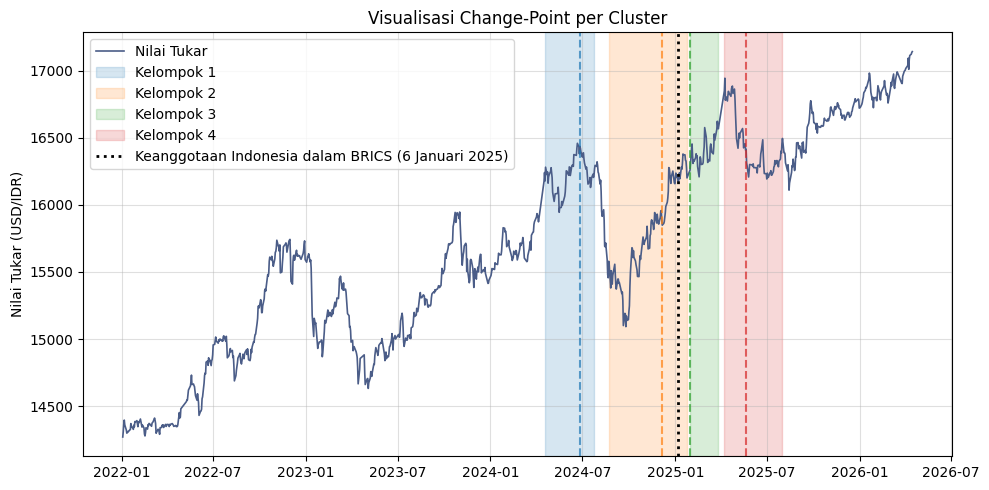

In [ ]:
# Visualisasi Change Point per Cluster
target_date = pd.Timestamp("2025-01-06")
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Nilai"], color=main_color, linewidth=1.2, label="Nilai Tukar")
colors = plt.cm.tab10.colors
for i, row in cluster_df.iterrows():
    if i == 4:
        continue
    c = colors[i % len(colors)]
    plt.axvspan(row["Start"], row["End"], color=c, alpha=0.18, label=f"Kelompok {i + 1}")
    plt.axvline(row["PeakDate"], color=c, linestyle="--", linewidth=1.5, alpha=0.7)

plt.axvline(
    target_date,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Keanggotaan Indonesia dalam BRICS (6 Januari 2025)"
)

plt.title("Visualisasi Change-Point per Cluster")
plt.ylabel("Nilai Tukar (USD/IDR)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# **Pembagian Data Pra dan Pasca Change Point**

In [ ]:
# Pembagian Data Berdasarkan Change Point
boundary_date = pd.to_datetime("2025-01-30")
df_era1 = df[df.index < boundary_date].copy()
df_era2 = df[df.index >= boundary_date].copy()

In [ ]:
# Ringkasan Pembagian Data
era1_pct = len(df_era1) / len(df) * 100
era2_pct = len(df_era2) / len(df) * 100
ringkasan = pd.DataFrame({
    "Keterangan": [
        "Jumlah Observasi",
        "Tanggal Awal",
        "Tanggal Akhir",
        "Persentase (%)"
    ],
    "Era Pra-BRICS": [
        len(df_era1),
        df_era1.index.min().date(),
        df_era1.index.max().date(),
        f"{era1_pct:.2f}"
    ],
    "Era Pasca-BRICS": [
        len(df_era2),
        df_era2.index.min().date(),
        df_era2.index.max().date(),
        f"{era2_pct:.2f}"
    ]
})

display(ringkasan)

,Keterangan,Era Pra-BRICS,Era Pasca-BRICS
0,Jumlah Observasi,740,285
1,Tanggal Awal,2022-01-03,2025-01-30
2,Tanggal Akhir,2025-01-24,2026-04-15
3,Persentase (%),72.20,27.80


# **Analisis Volatilitas**

In [ ]:
# Perhitungan Return dan Standar Deviasi
window = 20
df_return_era1 = df_return[df_return.index < boundary_date].copy()
df_return_era2 = df_return[df_return.index >= boundary_date].copy()
df_return_era1 = df_return_era1.dropna(subset = ["Return"])
df_return_era2 = df_return_era2.dropna(subset = ["Return"])
std_era1 = df_return_era1["Return"].std()
std_era2 = df_return_era2["Return"].std()

hasil_std = pd.DataFrame({
    "Era Pra-BRICS": [std_era1],
    "Era Pasca-BRICS": [std_era2]
}, index=["Standar Deviasi Return"])

display(hasil_std)

,Era Pra-BRICS,Era Pasca-BRICS
Standar Deviasi Return,0.003517,0.003087


In [ ]:
# Perhitungan Moving Standard Deviation
df_return_era1["Moving_Std"] = df_return_era1["Return"].rolling(window=window).std()
df_return_era2["Moving_Std"] = df_return_era2["Return"].rolling(window=window).std()

Moving_stdev = pd.DataFrame({
    "Era Pra-BRICS": [
        df_return_era1["Moving_Std"].mean(),
        df_return_era1["Moving_Std"].min(),
        df_return_era1["Moving_Std"].max()
    ],
    "Era Pasca-BRICS": [
        df_return_era2["Moving_Std"].mean(),
        df_return_era2["Moving_Std"].min(),
        df_return_era2["Moving_Std"].max()
    ]
}, index=[
    "Rata-rata Moving Standard Deviation",
    "Minimum Moving Standard Deviation",
    "Maksimum Moving Standard Deviation"
])

display(Moving_stdev)

,Era Pra-BRICS,Era Pasca-BRICS
Rata-rata Moving Standard Deviation,0.003298,0.002882
Minimum Moving Standard Deviation,0.000728,0.001166
Maksimum Moving Standard Deviation,0.006537,0.006009


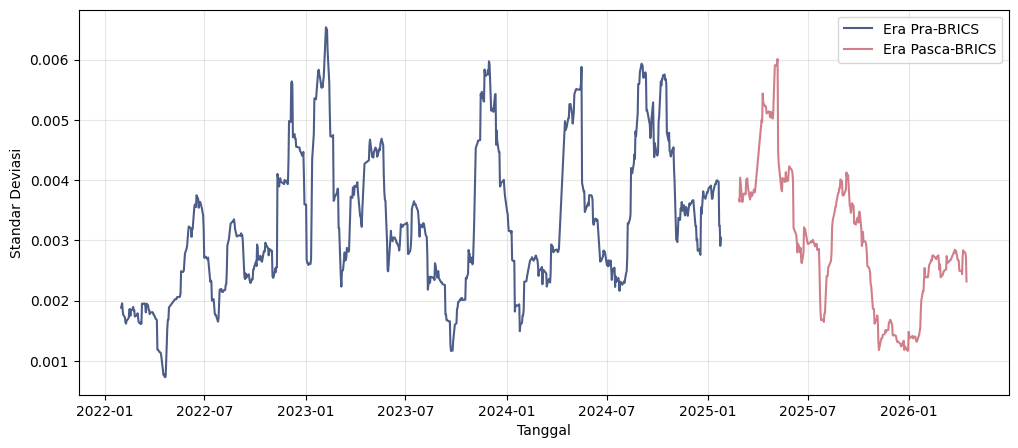

In [ ]:
# Visualisasi Volatilitas
plt.figure(figsize = (12, 5))
plt.plot(df_return_era1["Moving_Std"], color = '#4B5D88', label = "Era Pra-BRICS")
plt.plot(df_return_era2["Moving_Std"], color = '#D07E89', label = "Era Pasca-BRICS")
plt.xlabel("Tanggal")
plt.ylabel("Standar Deviasi")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Pembersihan Variabel
df = df.drop(columns=["Return"], errors="ignore")

# **Pemodelan XGBoost**

### Splitting Data (Train-Test)

In [ ]:
# Pemisahan Data Train dan Data Test
def split(df_era, test_size = 0.2):
    split_idx = int(len(df_era) * (1 - test_size))
    return df_era.iloc[:split_idx].copy(), df_era.iloc[split_idx:].copy()

In [ ]:
# Penerapan Pemisahan Data
raw_train_era1, raw_test_era1 = split(df_era1)
raw_train_era2, raw_test_era2 = split(df_era2)

print("Ringkasan Pembagian Data")
print(f"Era Pra-BRICS - Data Train: {len(raw_train_era1)}, Data Test: {len(raw_test_era1)}")
print(f"Era Pasca-BRICS - Data Train: {len(raw_train_era2)}, Data Test: {len(raw_test_era2)}")

Ringkasan Pembagian Data
Era Pra-BRICS - Data Train: 592, Data Test: 148
Era Pasca-BRICS - Data Train: 228, Data Test: 57


In [ ]:
# Visualisasi Pemisahan Data
main_color = "#4B5D88"
accent_color = "#D07E89"
def plot_train_test(raw_train, raw_test, target_col="Nilai", era_name=""):
    raw_train = raw_train.sort_index()
    raw_test = raw_test.sort_index()

    plt.figure(figsize=(8, 5))

    # Plot train & test
    plt.plot(raw_train.index, raw_train[target_col],
             label="Data Train",
             linewidth=1.5,
             color=main_color)

    plt.plot(raw_test.index, raw_test[target_col],
             label="Data Test",
             linewidth=1.5,
             color=accent_color)

    # Garis split
    split_date = raw_test.index.min()
    plt.axvline(split_date,
                linestyle="--",
                linewidth=1.5,
                color="black",
                label="Split Data")

    # Styling
    plt.title(f"Pembagian Data Train dan Test {era_name}")
    plt.ylabel("Nilai Tukar (USD/IDR)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

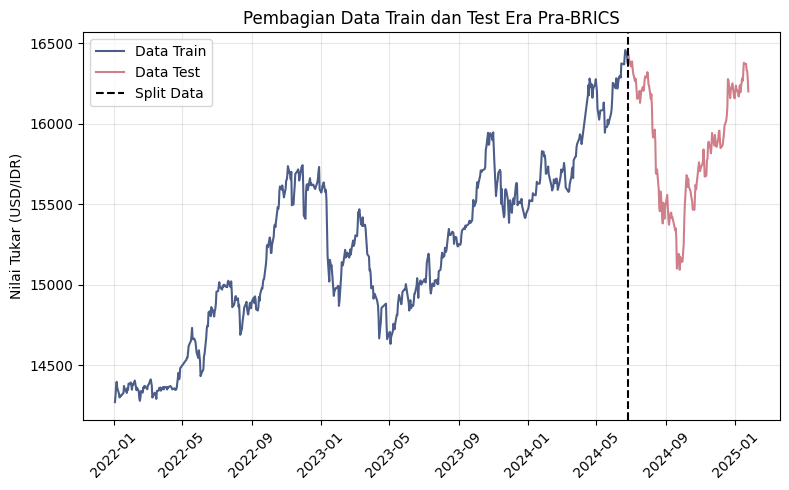

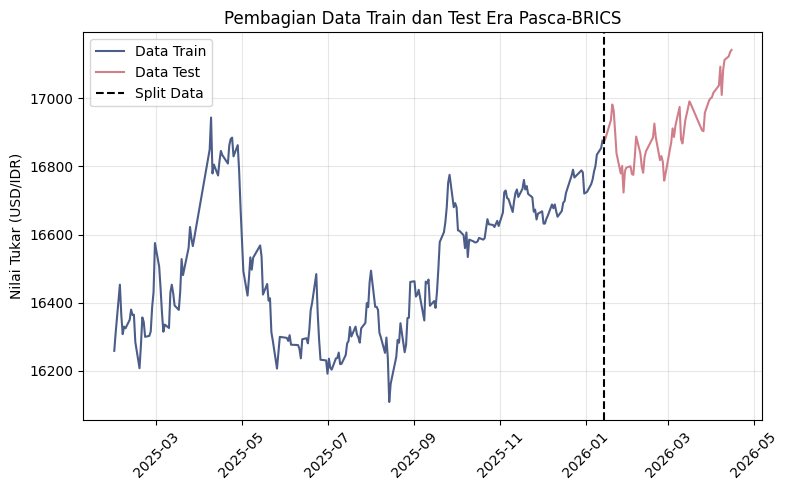

In [ ]:
# Run Visualisasi
plot_train_test(raw_train_era1, raw_test_era1, target_col="Nilai", era_name = "Era Pra-BRICS")
plot_train_test(raw_train_era2, raw_test_era2, target_col="Nilai", era_name = "Era Pasca-BRICS")

### Feature Engineering

In [ ]:
# Feature Engineering
def create_features(df, drop_missing=True):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df["Nilai"] = pd.to_numeric(df["Nilai"], errors = "coerce")

    # Target
    df["Target"] = df["Nilai"].diff()

    # Fitur
    df["dow"] = df.index.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)
    for lag in [1, 2, 3, 5, 10]:
        df[f"lag_{lag}"] = df["Nilai"].shift(lag)
    df["ma_5"] = df["Nilai"].rolling(5).mean().shift(1)
    df["ma_10"] = df["Nilai"].rolling(10).mean().shift(1)
    df["vol_5"] = df["Nilai"].rolling(5).std().shift(1)

    df = df.replace([np.inf, -np.inf], np.nan)

    if drop_missing:
        return df.dropna()

    return df

In [ ]:
# Penerapan Feature Engineering
train_era1_feat = create_features(raw_train_era1)
test_era1_feat = create_features(raw_test_era1)

train_era2_feat = create_features(raw_train_era2)
test_era2_feat = create_features(raw_test_era2)

In [ ]:
train_era1_feat

,Nilai,Target,dow,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_5,lag_10,ma_5,ma_10,vol_5
Tanggal,,,,,,,,,,,,,,,
2022-01-17,14323,13.0,0,0.000000,1.000000,5.000000e-01,0.866025,14310.0,14311.0,14302.0,14323.0,14270.0,14309.0,14324.6,9.354143
2022-01-18,14325,2.0,1,0.781831,0.623490,5.000000e-01,0.866025,14323.0,14310.0,14311.0,14299.0,14310.0,14309.0,14329.9,9.354143
2022-01-19,14370,45.0,2,0.974928,-0.222521,5.000000e-01,0.866025,14325.0,14323.0,14310.0,14302.0,14365.0,14314.2,14331.4,9.628084
2022-01-20,14354,-16.0,3,0.433884,-0.900969,5.000000e-01,0.866025,14370.0,14325.0,14323.0,14311.0,14396.0,14327.8,14331.9,24.549949
2022-01-21,14347,-7.0,4,-0.433884,-0.900969,5.000000e-01,0.866025,14354.0,14370.0,14325.0,14310.0,14360.0,14336.4,14327.7,24.724482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-19,16368,-6.0,2,0.974928,-0.222521,1.224647e-16,-1.000000,16374.0,16286.0,16297.0,16290.0,16225.0,16308.4,16276.6,36.922893
2024-06-20,16420,52.0,3,0.433884,-0.900969,1.224647e-16,-1.000000,16368.0,16374.0,16286.0,16295.0,16220.0,16324.0,16290.9,43.156691
2024-06-21,16458,38.0,4,-0.433884,-0.900969,1.224647e-16,-1.000000,16420.0,16368.0,16374.0,16297.0,16282.0,16349.0,16310.9,56.347138


In [ ]:
# Persiapan Data Model
def prepare_data(df_train, df_test):
    drop_cols = ["Nilai", "Target", "Return"]
    X_train = df_train.drop(columns = drop_cols, errors = "ignore")
    y_train = df_train["Target"]
    X_test = df_test.drop(columns = drop_cols, errors = "ignore")
    y_test = df_test["Target"]

    return X_train, y_train, X_test, y_test

In [ ]:
# Pembentukan Data Train dan Data Test
X_train_1, y_train_1, X_test_1, y_test_1 = prepare_data(train_era1_feat, test_era1_feat)
X_train_2, y_train_2, X_test_2, y_test_2 = prepare_data(train_era2_feat, test_era2_feat)

### Grid Search

In [ ]:
# Fungsi Grid Search XGBoost
def run(X_train, y_train, X_test, y_test, train_feat, test_feat, era_name):

    if len(X_train) < 20:
        return None

    xgb_model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        random_state = 42,
        n_jobs = -1
    )

    param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [2, 3],
    "learning_rate": [0.02, 0.03],
    "min_child_weight": [3, 4],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "gamma": [0.1, 0.2],
    "reg_alpha": [0.4, 0.5],
    "reg_lambda": [3, 4]
    }

    grid = GridSearchCV(
        estimator = xgb_model,
        param_grid = param_grid,
        cv = TimeSeriesSplit(n_splits = 5),
        scoring = "neg_mean_squared_error",
        verbose = 1,
        n_jobs = 1
    )

    grid.fit(X_train, y_train)
    model = grid.best_estimator_

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    pred_train = train_feat["lag_1"] + y_pred_train
    pred_test = test_feat["lag_1"] + y_pred_test

    actual_train = train_feat["Nilai"]
    actual_test = test_feat["Nilai"]

    train_mape = mean_absolute_percentage_error(actual_train, pred_train) * 100
    test_mape = mean_absolute_percentage_error(actual_test, pred_test) * 100

    train_rmse = np.sqrt(mean_squared_error(actual_train, pred_train))
    test_rmse = np.sqrt(mean_squared_error(actual_test, pred_test))

    return {
        "model": model,
        "params": grid.best_params_,
        "mape_train": train_mape,
        "mape_test": test_mape,
        "rmse_train": train_rmse,
        "rmse_test": test_rmse,
        "pred_train": pd.Series(pred_train, index=X_train.index),
        "pred_test": pd.Series(pred_test, index=X_test.index)
    }

In [ ]:
# Run Grid Search
results = {
    "era1": run(X_train_1, y_train_1, X_test_1, y_test_1, train_era1_feat, test_era1_feat, "Era Pra-BRICS"),
    "era2": run(X_train_2, y_train_2, X_test_2, y_test_2, train_era2_feat, test_era2_feat, "Era Pasca-BRICS")
}

res_era1 = results["era1"]
res_era2 = results["era2"]

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Fitting 5 folds for each of 512 candidates, totalling 2560 fits


In [ ]:
# Tabel Parameter Terbaik
best_params_era1 = res_era1["params"] if res_era1 else {}
best_params_era2 = res_era2["params"] if res_era2 else {}

all_params = sorted(set(best_params_era1.keys()) | set(best_params_era2.keys()))
tabel_params = pd.DataFrame({
    "Parameter": all_params,
    "Era Pra-BRICS": [best_params_era1.get(param, None) for param in all_params],
    "Era Pasca-BRICS": [best_params_era2.get(param, None) for param in all_params]
})

display(tabel_params)

,Parameter,Era Pra-BRICS,Era Pasca-BRICS
0,colsample_bytree,0.70,0.80
1,gamma,0.10,0.10
2,learning_rate,0.02,0.02
3,max_depth,2.00,3.00
4,min_child_weight,4.00,4.00
5,n_estimators,100.00,100.00
6,reg_alpha,0.50,0.50
7,reg_lambda,4.00,4.00
8,subsample,0.70,0.70


### Hasil Evaluasi

In [ ]:
# Tabel Perbandingan Kinerja Model
tr_mape1 = res_era1["mape_train"]
ts_mape1 = res_era1["mape_test"]
tr_rmse1 = res_era1["rmse_train"]
ts_rmse1 = res_era1["rmse_test"]

tr_mape2 = res_era2["mape_train"]
ts_mape2 = res_era2["mape_test"]
tr_rmse2 = res_era2["rmse_train"]
ts_rmse2 = res_era2["rmse_test"]

ratio1 = ts_mape1 / max(tr_mape1, 0.0001)
ratio2 = ts_mape2 / max(tr_mape2, 0.0001)

tabel_eval = pd.DataFrame({
    "Metrik": [
        "Train MAPE",
        "Test MAPE",
        "Rasio Test terhadap Train",
        "Train RMSE",
        "Test RMSE"
    ],
    "Era Pra-BRICS": [
        f"{tr_mape1:.3f}%",
        f"{ts_mape1:.3f}%",
        f"{ratio1:.3f}",
        f"{tr_rmse1:.3f}",
        f"{ts_rmse1:.3f}"
    ],
    "Era Pasca-BRICS": [
        f"{tr_mape2:.3f}%",
        f"{ts_mape2:.3f}%",
        f"{ratio2:.3f}",
        f"{tr_rmse2:.3f}",
        f"{ts_rmse2:.3f}"
    ]
})

display(tabel_eval)


,Metrik,Era Pra-BRICS,Era Pasca-BRICS
0,Train MAPE,0.231%,0.190%
1,Test MAPE,0.334%,0.249%
2,Rasio Test terhadap Train,1.444,1.309
3,Train RMSE,49.640,42.596
4,Test RMSE,66.732,48.583


In [ ]:
# Tabel Perubahan Kinerja Model
perubahan_mape = ((ts_mape2 - ts_mape1) / ts_mape1) * 100
perubahan_rmse = ((ts_rmse2 - ts_rmse1) / ts_rmse1) * 100

tabel_perubahan = pd.DataFrame({
    "Metrik": ["MAPE", "RMSE"],
    "Era Pra-BRICS": [
        f"{ts_mape1:.3f}%",
        f"{ts_rmse1:.3f}"
    ],
    "Era Pasca-BRICS": [
        f"{ts_mape2:.3f}%",
        f"{ts_rmse2:.3f}"
    ],
    "Perubahan (%)": [
        f"{perubahan_mape:+.3f}%",
        f"{perubahan_rmse:+.3f}%"
    ]
})

display(tabel_perubahan)

,Metrik,Era Pra-BRICS,Era Pasca-BRICS,Perubahan (%)
0,MAPE,0.334%,0.249%,-25.373%
1,RMSE,66.732,48.583,-27.197%


### Visualisasi Actual vs Predicted

In [ ]:
# Fungsi Visualisasi Aktual dan Prediksi Keseluruhan
def visualisasi_full(X_train1, y_train1, X_test1, y_test1, params1,
                   X_train2 = None, y_train2 = None, X_test2 = None, y_test2 = None, params2 = None):
    has_era2 = (X_train2 is not None) and (len(X_train2) > 0)
    fig, axes = plt.subplots(1, 2 if has_era2 else 1, figsize = (18, 6))

    if not has_era2:
        axes = [axes]

    # Era Pra-BRICS
    model1 = xgb.XGBRegressor(**params1, n_jobs = -1, random_state = 42, objective = "reg:squarederror")
    model1.fit(X_train1, y_train1)

    pred_diff_train1 = model1.predict(X_train1)
    pred_diff_test1 = model1.predict(X_test1)

    y_pred_train1 = train_era1_feat["lag_1"] + pred_diff_train1
    y_pred_test1 = test_era1_feat["lag_1"] + pred_diff_test1

    actual_train1 = train_era1_feat["Nilai"]
    actual_test1 = test_era1_feat["Nilai"]

    train_mape1 = mean_absolute_percentage_error(actual_train1, y_pred_train1) * 100
    test_mape1 = mean_absolute_percentage_error(actual_test1, y_pred_test1) * 100

    y_total_1 = pd.concat([actual_train1, actual_test1])
    y_pred_total_1 = pd.concat([
        pd.Series(y_pred_train1, index=X_train1.index),
        pd.Series(y_pred_test1, index=X_test1.index)
    ])

    axes[0].plot(y_total_1.index, y_total_1.values, label = "Data Aktual", linewidth = 2, color = "#483D8B")
    axes[0].plot(y_pred_total_1.index, y_pred_total_1.values, linestyle = "--", label = "Prediksi Model", linewidth = 2, color = "#D07E89")
    axes[0].axvline(X_test1.index.min(), linestyle="--", linewidth = 2, label = "Pemisahan Data Latih dan Uji", color = "black")
    axes[0].set_title(f"Era Pra-BRICS\nTest MAPE: {test_mape1:.2f}% (Train: {train_mape1:.2f}%)")
    axes[0].legend()
    axes[0].grid(True, alpha = 0.3)


    # Era Pasca-BRICS
    if has_era2:
        p2 = params2 if params2 else params1

        model2 = xgb.XGBRegressor(**p2, n_jobs = -1, random_state = 42, objective = "reg:squarederror")
        model2.fit(X_train2, y_train2)

        pred_diff_train2 = model2.predict(X_train2)
        pred_diff_test2 = model2.predict(X_test2)

        y_pred_train2 = train_era2_feat["lag_1"] + pred_diff_train2
        y_pred_test2 = test_era2_feat["lag_1"] + pred_diff_test2

        actual_train2 = train_era2_feat["Nilai"]
        actual_test2 = test_era2_feat["Nilai"]

        train_mape2 = mean_absolute_percentage_error(actual_train2, y_pred_train2) * 100
        test_mape2 = mean_absolute_percentage_error(actual_test2, y_pred_test2) * 100

        y_total_2 = pd.concat([actual_train2, actual_test2])
        y_pred_total_2 = pd.concat([
            pd.Series(y_pred_train2, index = X_train2.index),
            pd.Series(y_pred_test2, index = X_test2.index)
        ])

        axes[1].plot(y_total_2.index, y_total_2.values, label = "Data Aktual", linewidth = 2, color = "#483D8B")
        axes[1].plot(y_pred_total_2.index, y_pred_total_2.values, linestyle = "--", label = "Prediksi Model", linewidth = 2, color = "#D07E89")
        axes[1].axvline(X_test2.index.min(), linestyle = "--", linewidth = 2, label = "Pemisahan Data Latih dan Uji", color = "black")
        axes[1].set_title(f"Era Pasca-BRICS\nTest MAPE: {test_mape2:.2f}% (Train: {train_mape2:.2f}%)")
        axes[1].legend()
        axes[1].grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.show()

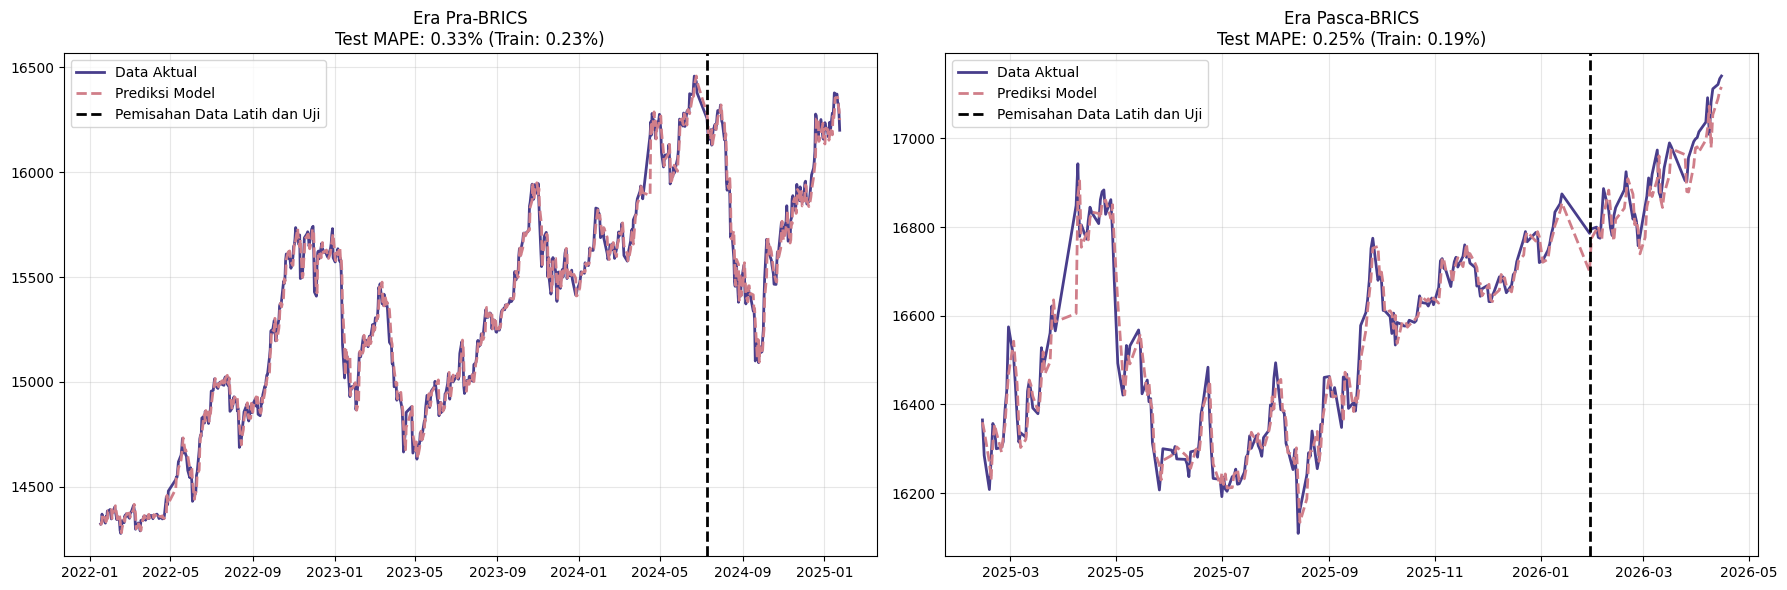

In [ ]:
# Run Visualisasi Keseluruhan
visualisasi_full(
    X_train_1, y_train_1, X_test_1, y_test_1, res_era1["params"],
    X_train_2, y_train_2, X_test_2, y_test_2, res_era2["params"]
)

In [ ]:
# Fungsi Visualisasi Perbandingan Data Latih dan Uji
def visualisasi(X_train1, y_train1, X_test1, y_test1, params1,
                    train_feat1, test_feat1,
                    X_train2 = None, y_train2 = None, X_test2 = None, y_test2 = None, params2 = None,
                    train_feat2 = None, test_feat2 = None):

    def plot(X_train, y_train, X_test, y_test, params, train_feat, test_feat):

        model = xgb.XGBRegressor(**params, objective = "reg:squarederror", random_state = 42, n_jobs = -1)
        model.fit(X_train, y_train)

        # Prediksi diff
        pred_diff_train = model.predict(X_train)
        pred_diff_test = model.predict(X_test)

        # Rekonstruksi
        y_pred_train = train_feat["lag_1"] + pred_diff_train
        y_pred_test = test_feat["lag_1"] + pred_diff_test

        actual_train = train_feat["Nilai"]
        actual_test = test_feat["Nilai"]

        y_all = np.concatenate([actual_train.values, actual_test.values])
        y_min = y_all.min() - 50
        y_max = y_all.max() + 50

        fig, ax = plt.subplots(1, 2, figsize=(18, 6))

        # Train
        ax[0].plot(actual_train.index, actual_train, label = "Data Aktual", color = "#483D8B")
        ax[0].plot(y_pred_train.index, y_pred_train, linestyle = "--", label = "Prediksi", color = "#D07E89")
        ax[0].set_ylim(y_min, y_max)
        ax[0].set_title("Data Latih")
        ax[0].legend()
        ax[0].grid(True, alpha = 0.3)

        # Test
        ax[1].plot(actual_test.index, actual_test, label = "Data Aktual", color = "#483D8B")
        ax[1].plot(y_pred_test.index, y_pred_test, linestyle = "--", label = "Prediksi", color = "#D07E89")
        ax[1].set_ylim(y_min, y_max)
        ax[1].set_title("Data Uji")
        ax[1].legend()
        ax[1].grid(True, alpha = 0.3)

        plt.tight_layout()
        plt.show()

    # Era 1
    plot(X_train1, y_train1, X_test1, y_test1, params1, train_feat1, test_feat1)

    # Era 2
    if X_train2 is not None:
        p2 = params2 if params2 else params1
        plot(X_train2, y_train2, X_test2, y_test2, p2, train_feat2, test_feat2)

In [ ]:
# Fungsi Visualisasi Perbandingan Data Latih dan Uji
def visualisasi(X_train1, y_train1, X_test1, y_test1, params1,
                train_feat1, test_feat1,
                X_train2=None, y_train2=None, X_test2=None, y_test2=None, params2=None,
                train_feat2=None, test_feat2=None):

    def plot(X_train, y_train, X_test, y_test, params, train_feat, test_feat, judul):

        model = xgb.XGBRegressor(
            **params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        # Prediksi diff
        pred_diff_train = model.predict(X_train)
        pred_diff_test = model.predict(X_test)

        # Rekonstruksi ke level nilai tukar
        y_pred_train = train_feat["lag_1"] + pred_diff_train
        y_pred_test = test_feat["lag_1"] + pred_diff_test

        actual_train = train_feat["Nilai"]
        actual_test = test_feat["Nilai"]

        # Gabungkan aktual dan prediksi
        actual_all = pd.concat([actual_train, actual_test])
        pred_all = pd.concat([y_pred_train, y_pred_test])

        batas_test = actual_test.index[0]

        y_all = np.concatenate([actual_all.values, pred_all.values])
        y_min = y_all.min() - 50
        y_max = y_all.max() + 50

        plt.figure(figsize=(12, 5))

        plt.plot(
            actual_all.index,
            actual_all,
            label="Data Aktual",
            color="#483D8B",
            linewidth=2
        )

        plt.plot(
            pred_all.index,
            pred_all,
            label="Prediksi",
            color="#D07E89",
            linestyle="--",
            linewidth=2
        )

        plt.axvline(
            x=batas_test,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="Batas Data Latih dan Uji"
        )

        plt.title(judul)
        plt.xlabel("Tanggal")
        plt.ylabel("Nilai Tukar USD/IDR")
        plt.ylim(y_min, y_max)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Era 1
    plot(
        X_train1, y_train1, X_test1, y_test1,
        params1, train_feat1, test_feat1,
        "Perbandingan Data Aktual dan Prediksi Era Pra-BRICS"
    )

    # Era 2
    if X_train2 is not None:
        p2 = params2 if params2 else params1

        plot(
            X_train2, y_train2, X_test2, y_test2,
            p2, train_feat2, test_feat2,
            "Perbandingan Data Aktual dan Prediksi Era Pasca-BRICS"
        )

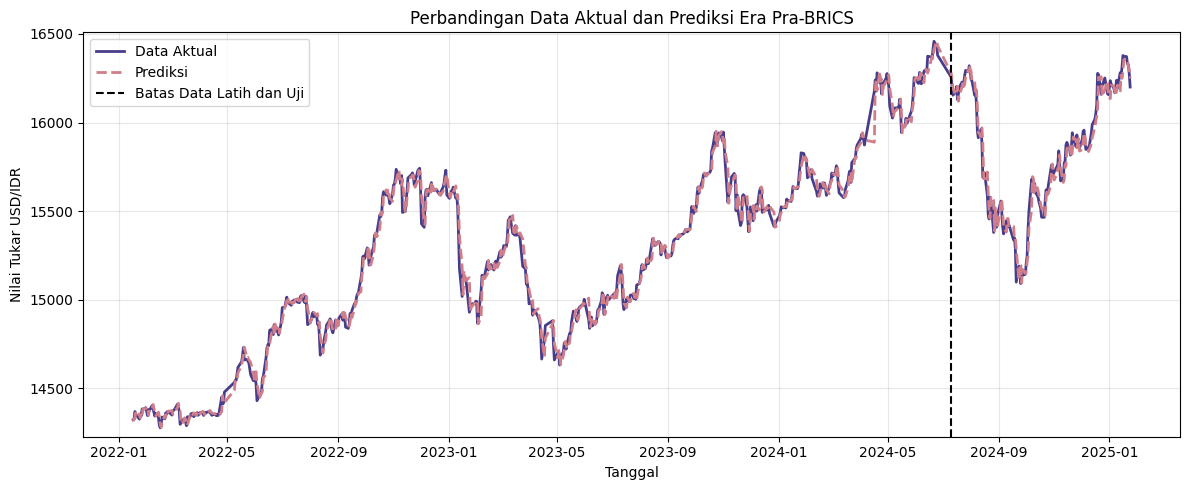

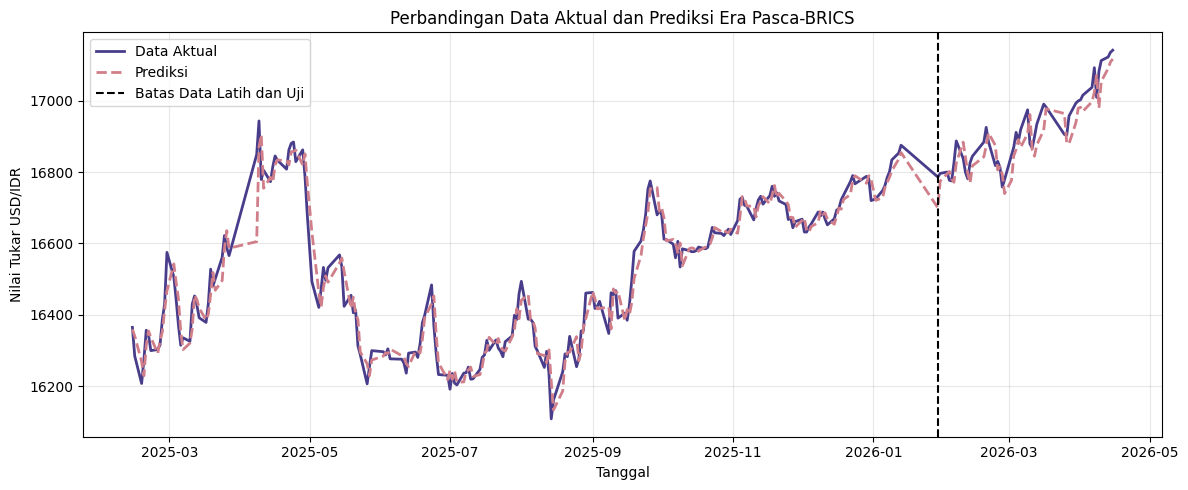

In [ ]:
# Run Visualisasi Perbandingan
visualisasi(
    X_train_1, y_train_1, X_test_1, y_test_1, res_era1["params"], train_era1_feat, test_era1_feat,
    X_train_2, y_train_2, X_test_2, y_test_2, res_era2["params"], train_era2_feat, test_era2_feat
)

In [ ]:
# Fungsi Deviasi Maksimum
def Deviasi(X_test, model, test_feat):
    pred_diff = model.predict(X_test)
    y_pred = test_feat["lag_1"] + pred_diff
    actual = test_feat["Nilai"]
    abs_diff = np.abs(actual - y_pred)
    max_dev = abs_diff.max()
    date_max_dev = abs_diff.idxmax()
    actual_value = actual.loc[date_max_dev]
    predicted_value = y_pred.loc[date_max_dev]
    return date_max_dev, max_dev, actual_value, predicted_value

In [ ]:
# Run Deviasi Maksimum
model1 = res_era1["model"]
model2 = res_era2["model"]
date1, dev1, act1, pred1 = Deviasi(X_test_1, model1, test_era1_feat)
print(f"Era Pra-BRICS: {date1}, Deviasi: {dev1:.3f}, Aktual: {act1:.3f}, Prediksi: {pred1:.3f}")
date2, dev2, act2, pred2 = Deviasi(X_test_2, model2, test_era2_feat)
print(f"Era Pasca-BRICS: {date2}, Deviasi: {dev2:.3f}, Aktual: {act2:.3f}, Prediksi: {pred2:.3f}")

Era Pra-BRICS: 2024-08-14 00:00:00, Deviasi: 198.522, Aktual: 15691.000, Prediksi: 15889.522
Era Pasca-BRICS: 2026-04-09 00:00:00, Deviasi: 102.694, Aktual: 17082.000, Prediksi: 16979.306


### Feature Importance

In [ ]:
# Ambil Model Terlatih
model_era1 = results["era1"]["model"]
model_era2 = results["era2"]["model"] if results["era2"] else None

In [ ]:
# Hitung Feature Importance
fi_era1 = pd.DataFrame({
    "Feature": X_train_1.columns,
    "Importance_Era1": model_era1.feature_importances_
}).sort_values("Importance_Era1", ascending = False)
fi_era2 = pd.DataFrame()

fi_era2 = pd.DataFrame({
    "Feature": X_train_2.columns,
    "Importance_Era2": model_era2.feature_importances_
}).sort_values("Importance_Era2", ascending = False)

In [ ]:
# Analisis Perubahan Importance
fi_combined = pd.merge(fi_era1, fi_era2, on = "Feature", how = "outer").fillna(0)
fi_combined["Change"] = fi_combined["Importance_Era2"] - fi_combined["Importance_Era1"]

top_changes = fi_combined.reindex(
    fi_combined["Change"].abs().sort_values(ascending=False).index
)

print(top_changes[["Feature", "Importance_Era1", "Importance_Era2", "Change"]].to_string(index = False))

  Feature  Importance_Era1  Importance_Era2    Change
    ma_10         0.069390         0.092094  0.022704
    lag_3         0.088748         0.067933 -0.020815
month_cos         0.097980         0.078484 -0.019496
     ma_5         0.086305         0.068391 -0.017913
  dow_sin         0.066507         0.084050  0.017543
    vol_5         0.060643         0.074891  0.014248
    lag_2         0.085487         0.077008 -0.008479
month_sin         0.068327         0.075683  0.007356
      dow         0.073025         0.066239 -0.006786
    lag_5         0.072148         0.077995  0.005848
  dow_cos         0.091709         0.095119  0.003410
   lag_10         0.066405         0.068135  0.001730
    lag_1         0.073326         0.073977  0.000651


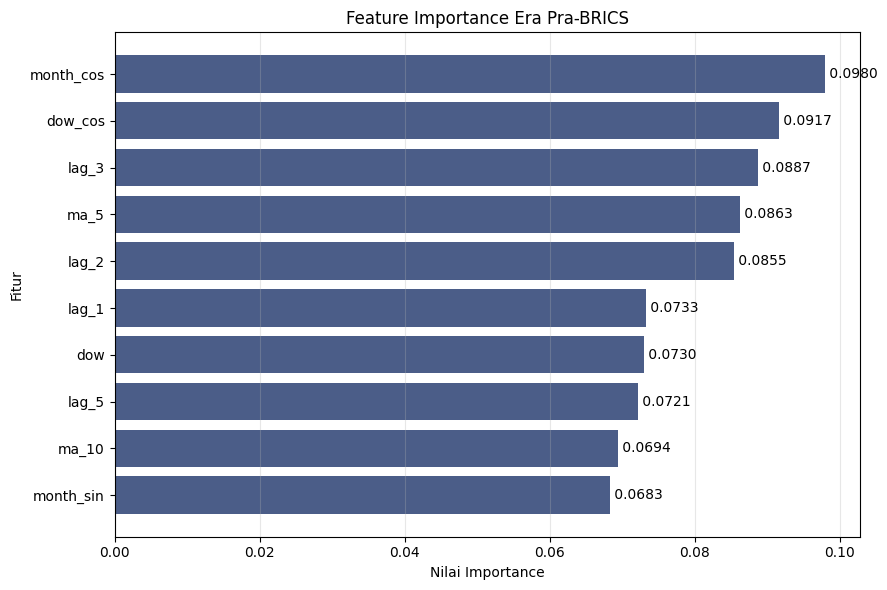

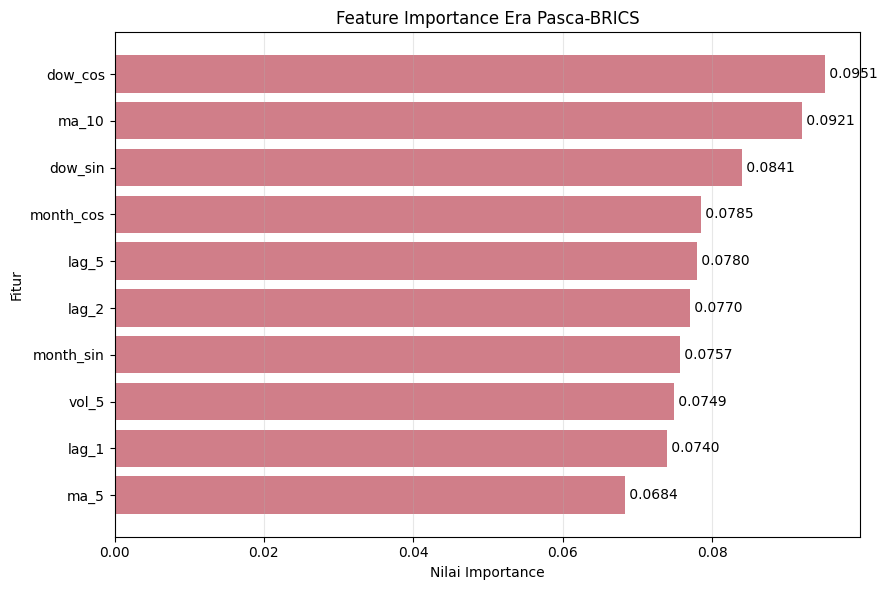

In [ ]:
# Visualisasi Feature Importance Era Pra-BRICS
top_10_era1 = fi_era1.head(10).sort_values("Importance_Era1", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(
    top_10_era1["Feature"],
    top_10_era1["Importance_Era1"],
    color="#4B5D88"
)

plt.title("Feature Importance Era Pra-BRICS")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")

for i, v in enumerate(top_10_era1["Importance_Era1"]):
    plt.text(v, i, f" {v:.4f}", va="center")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# Visualisasi Feature Importance Era Pasca-BRICS
if not fi_era2.empty:
    top_10_era2 = fi_era2.head(10).sort_values("Importance_Era2", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(
        top_10_era2["Feature"],
        top_10_era2["Importance_Era2"],
        color="#D07E89"
    )

    plt.title("Feature Importance Era Pasca-BRICS")
    plt.xlabel("Nilai Importance")
    plt.ylabel("Fitur")

    for i, v in enumerate(top_10_era2["Importance_Era2"]):
        plt.text(v, i, f" {v:.4f}", va="center")

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

# **Analisis Konsistensi**

In [ ]:
# Definisi Change Point
variasi_cp = [
    "2024-12-5",
    "2025-01-24"
]

variasi_cp = [pd.to_datetime(d) for d in variasi_cp]

In [ ]:
# Fungsi Volatilitas & Evaluasi
def Volatilitas(x):
    x = x.dropna()
    return pd.Series({
        "Variance": x.var(),
        "Std Dev": x.std()
    })

def evaluasi_cp(boundary_date, df):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df["Nilai"] = pd.to_numeric(df["Nilai"], errors = "coerce")
    df_era1 = df[df.index < boundary_date].copy()
    df_era2 = df[df.index >= boundary_date].copy()

    # Volatilitas Return
    df_era1["Return"] = np.log(df_era1["Nilai"] / df_era1["Nilai"].shift(1))
    df_era2["Return"] = np.log(df_era2["Nilai"] / df_era2["Nilai"].shift(1))
    Volatilitas_era1 = Volatilitas(df_era1["Return"])
    Volatilitas_era2 = Volatilitas(df_era2["Return"])

    # Splitting Data
    train_era1, test_era1 = split(df_era1)
    train_era2, test_era2 = split(df_era2)

    # Feature Engineering
    train_era1_feat = create_features(train_era1)
    test_era1_feat  = create_features(test_era1)

    train_era2_feat = create_features(train_era2)
    test_era2_feat  = create_features(test_era2)

    # Prepare Data
    X_train_1, y_train_1, X_test_1, y_test_1 = prepare_data(train_era1_feat, test_era1_feat)
    X_train_2, y_train_2, X_test_2, y_test_2 = prepare_data(train_era2_feat, test_era2_feat)

    # Run Model
    res_era1 = run(
        X_train_1, y_train_1, X_test_1, y_test_1,
        train_era1_feat, test_era1_feat, "Era Pra-BRICS"
    )
    res_era2 = run(
        X_train_2, y_train_2, X_test_2, y_test_2,
        train_era2_feat, test_era2_feat, "Era Pasca-BRICS"
    )

    if (res_era1 is None) or (res_era2 is None):
        return None

    out = {
        "CP": boundary_date.date(),
        "n_pra": len(df_era1),
        "n_pasca": len(df_era2),
        "sd_return_pra": Volatilitas_era1["Std Dev"],
        "sd_return_pasca": Volatilitas_era2["Std Dev"],
        "test_mape_pra": res_era1["mape_test"],
        "test_mape_pasca": res_era2["mape_test"],
        "test_rmse_pra": res_era1["rmse_test"],
        "test_rmse_pasca": res_era2["rmse_test"],
        "best_params_pra": res_era1["params"],
        "best_params_pasca": res_era2["params"]
    }

    out["delta_mape_pasca_vs_pra"] = out["test_mape_pasca"] - out["test_mape_pra"]
    out["delta_rmse_pasca_vs_pra"] = out["test_rmse_pasca"] - out["test_rmse_pra"]

    if out["delta_mape_pasca_vs_pra"] < 0 and out["delta_rmse_pasca_vs_pra"] < 0:
        out["kesimpulan"] = "Pasca lebih prediktabel"
    elif out["delta_mape_pasca_vs_pra"] > 0 and out["delta_rmse_pasca_vs_pra"] > 0:
        out["kesimpulan"] = "Pra lebih prediktabel"
    else:
        out["kesimpulan"] = "MAPE dan RMSE tidak searah"

    return out

In [ ]:
# Run Evaluasi Change Point
hasil_cp = []
for cp in variasi_cp:
    res_cp = evaluasi_cp(cp, df)
    if res_cp is not None:
        hasil_cp.append(res_cp)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Fitting 5 folds for each of 512 candidates, totalling 2560 fits


In [ ]:
# Hasil Evaluasi
hasil_cp_df = pd.DataFrame(hasil_cp)
rename_cols = {
    "n_pra": "Jumlah Data di Era Pra-BRICS",
    "n_pasca": "Jumlah Data di Era Pasca-BRICS",
    "sd_return_pra": "Volatilitas Era Pra-BRICS",
    "sd_return_pasca": "Volatilitas Era Pasca-BRICS",
    "test_mape_pra": "MAPE Era Pra-BRICS",
    "test_mape_pasca": "MAPE Era Pasca-BRICS",
    "test_rmse_pra": "RMSE Era Pra-BRICS",
    "test_rmse_pasca": "RMSE Era Pasca-BRICS",
    "kesimpulan": "Kesimpulan"
}

if not hasil_cp_df.empty:
    cols_show = ["CP"] + list(rename_cols.values())
    hasil_cp_tampil = hasil_cp_df.rename(columns = rename_cols)
    display(hasil_cp_tampil[cols_show])
else:
    print("Tidak terdapat hasil evaluasi change point yang valid.")

,CP,Jumlah Data di Era Pra-BRICS,Jumlah Data di Era Pasca-BRICS,Volatilitas Era Pra-BRICS,Volatilitas Era Pasca-BRICS,MAPE Era Pra-BRICS,MAPE Era Pasca-BRICS,RMSE Era Pra-BRICS,RMSE Era Pasca-BRICS,Kesimpulan
0,2024-12-05,706,319,0.003520,0.003124,0.330053,0.242859,65.177234,47.550630,Pasca lebih prediktabel
1,2025-01-24,739,286,0.003515,0.003087,0.331624,0.275419,66.588248,52.824682,Pasca lebih prediktabel


# **Peramalan**

In [ ]:
# Tanggal Peramalan
future_dates = pd.to_datetime([
    "2026-04-16", "2026-04-17",
    "2026-04-20", "2026-04-21",
    "2026-04-22", "2026-04-23",
    "2026-04-24", "2026-04-27",
    "2026-04-28", "2026-04-29"
])

In [ ]:
# Nilai Aktual
actual_values = [
    17142, 17189,
    17176, 17142,
    17179, 17308,
    17278, 17227,
    17245, 17324
]
actual_series = pd.Series(actual_values, index=future_dates, name="Aktual").astype(float)

In [ ]:
# Data
forecast_start = future_dates.min()
df_final_pasca = df_era2[df_era2.index < forecast_start].copy()
df_final_pasca_feat = create_features(df_final_pasca)

drop_cols = ["Nilai", "Target", "Return"]

X_final_pasca = df_final_pasca_feat.drop(columns=drop_cols, errors="ignore")
y_final_pasca = df_final_pasca_feat["Target"]

In [ ]:
# Train Model
model_pasca_brics = xgb.XGBRegressor(
    **res_era2["params"],
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
model_pasca_brics.fit(X_final_pasca, y_final_pasca)
feature_cols = X_final_pasca.columns

In [ ]:
# Data Historis Sebelum Periode Peramalan
history = df_era2[["Nilai"]].copy()
history = history[history.index < forecast_start].sort_index()

if len(history) < 20:
    raise ValueError("Data historis sebelum tanggal peramalan kurang dari 20 observasi.")

In [ ]:
# Recursive Forecasting
forecast_values = []
forecast_diff_values = []

work = history.copy()

for tgl in future_dates:
    temp = work.copy()
    temp.loc[tgl, "Nilai"] = np.nan
    temp = temp.sort_index()

    feat_all = create_features(temp, drop_missing=False)

    row_feat = feat_all.loc[[tgl], feature_cols]

    pred_diff = float(model_pasca_brics.predict(row_feat)[0])

    last_value = work["Nilai"].iloc[-1]
    pred_level = last_value + pred_diff

    forecast_diff_values.append(pred_diff)
    forecast_values.append(pred_level)

    work.loc[tgl, "Nilai"] = pred_level
    work = work.sort_index()

In [ ]:
# Tabel hasil peramalan
hasil_peramalan = pd.DataFrame({
    "Tanggal": future_dates,
    "Aktual": actual_values,
    "Prediksi": forecast_values,
    "Prediksi Diff": forecast_diff_values
})

hasil_peramalan["Error"] = hasil_peramalan["Aktual"] - hasil_peramalan["Prediksi"]
hasil_peramalan["Absolute Error"] = hasil_peramalan["Error"].abs()
hasil_peramalan["APE (%)"] = (
    hasil_peramalan["Absolute Error"] / hasil_peramalan["Aktual"] * 100
)

display(hasil_peramalan.round(3))

,Tanggal,Aktual,Prediksi,Prediksi Diff,Error,Absolute Error,APE (%)
0,2026-04-16,17142,17149.533,8.533,-7.533,7.533,0.044
1,2026-04-17,17189,17158.853,9.319,30.147,30.147,0.175
2,2026-04-20,17176,17169.373,10.520,6.627,6.627,0.039
3,2026-04-21,17142,17178.458,9.085,-36.458,36.458,0.213
4,2026-04-22,17179,17183.233,4.775,-4.233,4.233,0.025
5,2026-04-23,17308,17191.767,8.533,116.233,116.233,0.672
6,2026-04-24,17278,17201.086,9.319,76.914,76.914,0.445
7,2026-04-27,17227,17211.606,10.520,15.394,15.394,0.089
8,2026-04-28,17245,17220.691,9.085,24.309,24.309,0.141
9,2026-04-29,17324,17225.466,4.775,98.534,98.534,0.569


In [ ]:
# Evaluasi
eval_df = hasil_peramalan.dropna(subset = ["Aktual"]).copy()

if not eval_df.empty:
    mape_forecast = mean_absolute_percentage_error(
        eval_df["Aktual"],
        eval_df["Prediksi"]
    ) * 100

    rmse_forecast = np.sqrt(mean_squared_error(
        eval_df["Aktual"],
        eval_df["Prediksi"]
    ))

    evaluasi_peramalan = pd.DataFrame({
        "Metrik": ["MAPE", "RMSE"],
        "Nilai": [
            f"{mape_forecast:.3f}%",
            f"{rmse_forecast:.3f}"
        ]
    })

    display(evaluasi_peramalan)
else:
    print("Belum ada nilai aktual untuk evaluasi MAPE dan RMSE.")

,Metrik,Nilai
0,MAPE,0.241%
1,RMSE,56.850


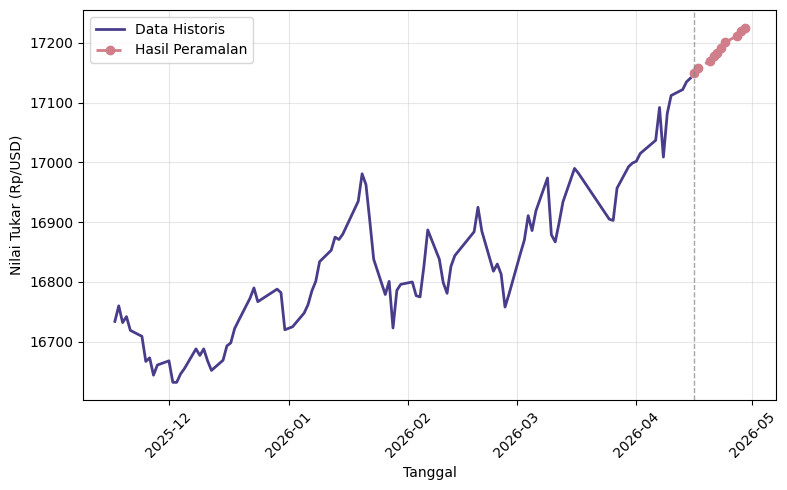

In [ ]:
# Visualisasi Historis + Prediksi
plt.figure(figsize=(8, 5))

cutoff_date = hasil_peramalan["Tanggal"].min()
df_recent = df[df.index >= cutoff_date - pd.DateOffset(months=5)]

plt.plot(
    df_recent.index,
    df_recent["Nilai"],
    linewidth=2,
    color="#483D8B",
    label="Data Historis"
)

plt.plot(
    hasil_peramalan["Tanggal"],
    hasil_peramalan["Prediksi"],
    marker="o",
    linestyle="--",
    linewidth=2,
    color="#D07E89",
    label="Hasil Peramalan"
)

plt.axvline(
    x=cutoff_date,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

plt.xlabel("Tanggal")
plt.ylabel("Nilai Tukar (Rp/USD)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()